<a href="https://colab.research.google.com/github/AliffiaHumrh/2311531004_AliffiaHumairah_ImageProcessing/blob/main/ImageProcessing_Pertemuan5_2311531004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

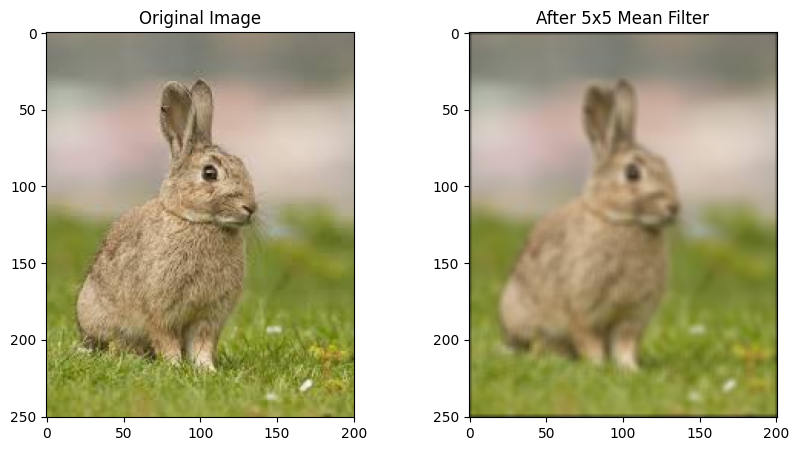

In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def manual_convolution(image_array, kernel):
    # Mendapatkan dimensi citra dan kernel
    img_height, img_width, channels = image_array.shape
    k_height, k_width = kernel.shape

    # Menghitung padding (untuk kernel 5x5, padding adalah 2)
    pad_h = k_height // 2
    pad_w = k_width // 2

    # Membuat canvas kosong untuk output
    output = np.zeros_like(image_array)

    # Menambahkan padding pada citra input (Zero Padding)
    padded_img = np.pad(image_array, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='constant')

    # Proses Konvolusi
    for c in range(channels): # Loop setiap warna R, G, B
        for y in range(img_height):
            for x in range(img_width):
                # Mengambil area sesuai ukuran kernel
                region = padded_img[y:y+k_height, x:x+k_width, c]
                # Operasi konvolusi: jumlah dari (region * kernel)
                # Karena kernel rataan 5x5 nilainya semua 1/25, ini sama dengan rata-rata
                output[y, x, c] = np.sum(region * kernel)

    return output.astype(np.uint8)

# 1. Load Citra
image_path = 'kelinci.jpg' # Ganti dengan nama file gambarmu
img = Image.open(image_path).convert('RGB')
img_array = np.array(img)

# 2. Definisi Kernel Rataan 5x5 (Linear Filter)
# Setiap elemen adalah 1/(5*5) = 1/25
kernel_size = 5
kernel_mean_5x5 = np.ones((kernel_size, kernel_size)) / (kernel_size**2)

# 3. Jalankan Konvolusi
result_array = manual_convolution(img_array, kernel_mean_5x5)

# 4. Tampilkan & Simpan Hasil
result_img = Image.fromarray(result_array)
result_img.save('hasil_konvolusi.jpg')

# Visualisasi sederhana
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_array)
plt.subplot(1, 2, 2)
plt.title("After 5x5 Mean Filter")
plt.imshow(result_array)
plt.show()